In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces /content/

In [ ]:
# !cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/

Dependencies and Imports...

In [ ]:
!pip install -q timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.0 MB/s eta 0:00:00


In [ ]:
import timm

import os
import random
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Reproducibility...

In [ ]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


Configurations...

In [ ]:
[x for x in timm.list_models() if 'xception' in x]

['legacy_xception',
 'xception41',
 'xception41p',
 'xception65',
 'xception65p',
 'xception71']

In [ ]:
model_name = 'xception65'

image_size = 299
batch_size = 32

learning_rate = 5e-5
weight_decay = 1e-4

maximum_epochs = 20
patience = 5

Dataset Path...

In [ ]:
root = '/content/drive/MyDrive/DL_Project/datasets'

ffpp_root = os.path.join(root, 'ffpp_cropped_faces')

celeb_root = os.path.join(root, 'celebv2_cropped_faces')

# ffpp_root = '/content/ffpp_cropped_faces'

# celeb_root = '/content/celebv2_cropped_faces'

Dataset Staistics...

In [ ]:
def count_images(folder):

    real = len(os.listdir(os.path.join(folder,'real')))
    fake = len(os.listdir(os.path.join(folder,'fake')))

    return real, fake

In [ ]:
for split in ['train','val','test']:
    real,fake = count_images(os.path.join(ffpp_root, split))

    print('\n', split,':', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


 train : real = 7500 | fake = 6869 | total = 14369

 val : real = 1250 | fake = 1130 | total = 2380

 test : real = 1250 | fake = 1138 | total = 2388


In [ ]:
real,fake = count_images(celeb_root)

print('\nceleb-df :', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


celeb-df : real = 2999 | fake = 2991 | total = 5990


Dataset Class...

In [ ]:
class DeepfakeDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        for img in os.listdir(real_dir):
            self.samples.append((os.path.join(real_dir,img), 0))

        for img in os.listdir(fake_dir):
            self.samples.append((os.path.join(fake_dir,img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,idx):

        path,label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label,dtype=torch.float32)

Transforms...

In [ ]:
imagenet_mean = [0.485,0.456,0.406]
imagenet_std = [0.229,0.224,0.225]

In [ ]:
train_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(imagenet_mean, imagenet_std)])

In [ ]:
test_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(imagenet_mean, imagenet_std)])

Dataloaders...

In [ ]:
train_ds = DeepfakeDataset(os.path.join(ffpp_root, 'train'), train_transform)

val_ds = DeepfakeDataset(os.path.join(ffpp_root, 'val'), test_transform)

test_ds = DeepfakeDataset(os.path.join(ffpp_root, 'test'), test_transform)

celeb_ds = DeepfakeDataset(celeb_root, test_transform)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

celeb_loader = DataLoader(celeb_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

In [ ]:
print('\nlength of train ffpp :', len(train_ds))
print('\nlength of val ffpp :', len(val_ds))
print('\nlength of test ffpp :', len(test_ds))
print('\nlength of celeb :', len(celeb_ds))


length of train ffpp : 14369

length of val ffpp : 2380

length of test ffpp : 2388

length of celeb : 5990


In [ ]:
next(iter(train_loader))[0].shape

torch.Size([32, 3, 299, 299])

Model...

In [ ]:
model = timm.create_model(model_name, pretrained=True, num_classes=1)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/160M [00:00<?, ?B/s]

In [ ]:
print(model.get_classifier())

Linear(in_features=2048, out_features=1, bias=True)


In [ ]:
total_parameters = sum(p.numel() for p in model.parameters())

print(f'\nparameters: {total_parameters:,}')


parameters: 37,869,361


Loss / Optimizer ...

In [ ]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

AMP...

In [ ]:
scaler = torch.amp.GradScaler('cuda')

Evaluation Function...

In [ ]:
@torch.no_grad()

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []

    for images, labels in tqdm(loader, leave=False):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze(1)
        labels = labels.float().view_as(outputs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    auc = roc_auc_score(all_labels, all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'auc': auc,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'preds': np.array(all_preds)
    }

Training Loop...

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'val_auc': [],
           'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}

best_auc = 0.0
patience_counter = 0

save_dir = '/content/drive/MyDrive/DL_Project/checkpoints'
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir,'best_xception65.pth')

In [ ]:
for epoch in range(maximum_epochs):

    print(f'\nepoch [{epoch+1}/{maximum_epochs}]')

    # training...

    model.train()

    running_loss = 0.0

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):

            outputs = model(images).squeeze(1)
            labels = labels.view_as(outputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}')

    train_loss = running_loss/len(train_loader.dataset)

    # validation..

    val_metrics = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_auc = val_metrics['auc']

    val_acc = val_metrics['accuracy']
    val_precision = val_metrics['precision']
    val_recall = val_metrics['recall']
    val_f1 = val_metrics['f1']

    scheduler.step(val_auc)

    history['train_loss'].append(train_loss)

    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    print(f'\ntrain loss  : {train_loss:.4f}')

    print(f'\nval loss  : {val_loss:.4f}')
    print(f'\nval auc  : {val_auc:.4f}')

    print(f'\nval accuracy  : {val_acc:.4f}')
    print(f'val precision  : {val_precision:.4f}')
    print(f'val recall  : {val_recall:.4f}')
    print(f'val f1  : {val_f1:.4f}')

    # early stopping..

    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0

        torch.save({'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_auc': best_auc},best_model_path)

        print(f'\nbest model saved (auc={best_auc:.4f})')

    else:
        patience_counter += 1
        print(f'\nno improvement ({patience_counter}/{patience})')

    if patience_counter >= patience:
        print('\nearly stopping triggered...')

        break


epoch [1/20]


  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.4514

val loss  : 9.0635

val auc  : 0.8675

val accuracy  : 0.8130
val precision  : 0.8253
val recall  : 0.7690
val f1  : 0.7962

best model saved (auc=0.8675)

epoch [2/20]


  0%|          | 0/450 [00:00<?, ?it/s]

...

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.0181

val loss  : 26.5005

val auc  : 0.9364

val accuracy  : 0.8782
val precision  : 0.8148
val recall  : 0.9619
val f1  : 0.8823

no improvement (4/5)

epoch [10/20]


  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.0108

val loss  : 4.0897

val auc  : 0.9240

val accuracy  : 0.8832
val precision  : 0.8282
val recall  : 0.9513
val f1  : 0.8855

no improvement (5/5)

early stopping triggered...


In [ ]:
history_df = pd.DataFrame(history)

results_dir = '/content/drive/MyDrive/DL_Project/results/xception_baseline/'

os.makedirs(results_dir, exist_ok=True)
history_df.to_csv(os.path.join(results_dir, 'xception65_training_history.csv'), index=False)

print('training history saved...')

training history saved...


Load Model Checkpoint...

In [ ]:
checkpoint_path = '/content/drive/MyDrive/DL_Project/checkpoints/best_xception65.pth'

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print(f'best epoch : {checkpoint['epoch']}')
print(f'best auc   : {checkpoint['best_auc']:.4f}')

best epoch : 5
best auc   : 0.9473


In [ ]:
print(len(test_loader.dataset))
print(len(celeb_loader.dataset))

2388
5990


Learning Curves...

In [ ]:
history_df = pd.read_csv('/content/drive/MyDrive/DL_Project/results/xception_baseline/xception65_training_history.csv')

In [ ]:
history_df['epoch'] = range(1,len(history_df) + 1)
history_df.head()

,train_loss,val_loss,val_auc,val_acc,val_precision,val_recall,val_f1,epoch
0,0.451397,9.063542,0.867465,0.813025,0.825261,0.769027,0.796152,1
1,0.171517,10.342439,0.913012,0.858824,0.880998,0.812389,0.845304,2
2,0.096596,1.706446,0.919385,0.872689,0.856158,0.879646,0.867743,3
3,0.075400,1.089973,0.932776,0.872269,0.828299,0.922124,0.872697,4
4,0.055281,1.074470,0.947297,0.879832,0.840872,0.921239,0.879223,5


In [ ]:
output_dir = '/content/drive/MyDrive/DL_Project/results/xception_baseline/'
os.makedirs(output_dir, exist_ok=True)

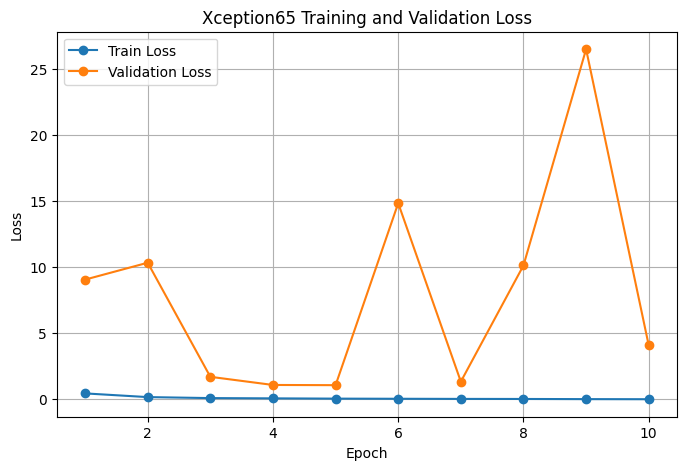

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')

plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Xception65 Training and Validation Loss')

plt.legend()
plt.grid(True)

save_path = os.path.join(output_dir, 'xception65_loss_plot.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

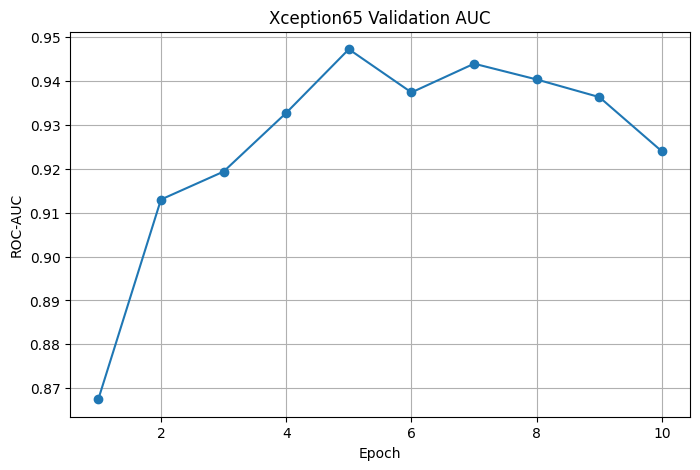

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['val_auc'], marker='o')

plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('Xception65 Validation AUC')

plt.grid(True)

save_path = os.path.join(output_dir, 'xception65_auc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

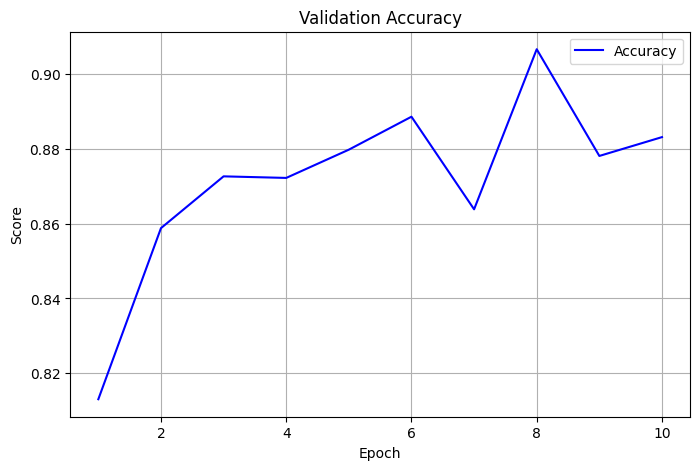

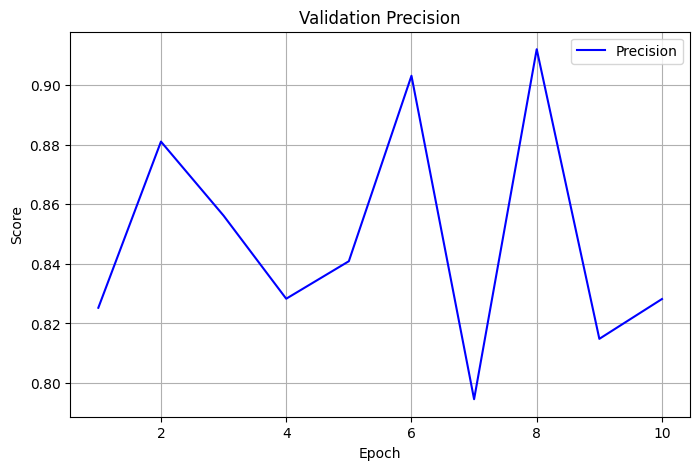

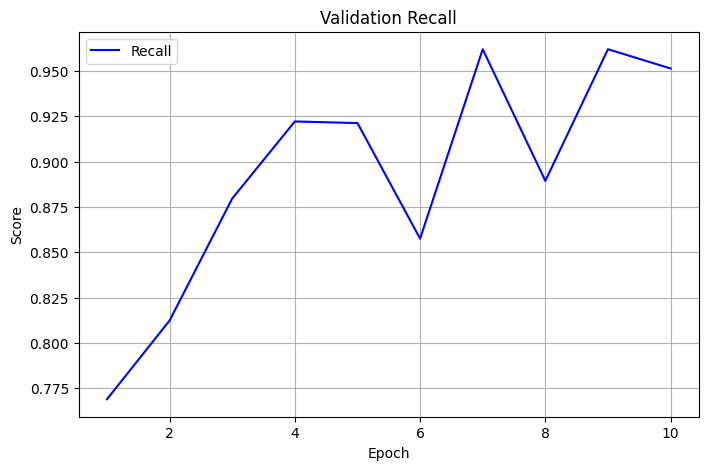

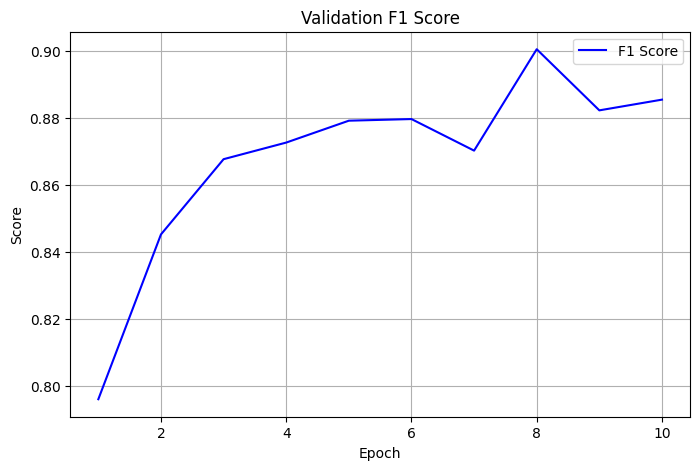

In [ ]:
metrics = ['val_acc', 'val_precision', 'val_recall', 'val_f1']
display_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric, name in zip(metrics, display_names):
    plt.figure(figsize=(8,5))

    plt.plot(history_df['epoch'], history_df[metric], label=name, color='blue')

    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title(f'Validation {name}')

    plt.legend()
    plt.grid(True)

    file_name = f'xception65_{metric}.pdf'
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, bbox_inches='tight')

    plt.show()

FF++ Evaluation...

In [ ]:
ffpp_metrics = evaluate(model, test_loader, criterion)

print('\nfaceforensics++ test results')

print(f'AUC  : {ffpp_metrics['auc']:.4f}')
print(f'Accuracy  : {ffpp_metrics['accuracy']:.4f}')
print(f'Precision  : {ffpp_metrics['precision']:.4f}')
print(f'Recall  : {ffpp_metrics['recall']:.4f}')
print(f'F1  : {ffpp_metrics['f1']:.4f}')

  0%|          | 0/75 [00:00<?, ?it/s]


faceforensics++ test results
AUC  : 0.9547
Accuracy  : 0.8978
Precision  : 0.8682
Recall  : 0.9262
F1  : 0.8963


FF++ ROC Curve...

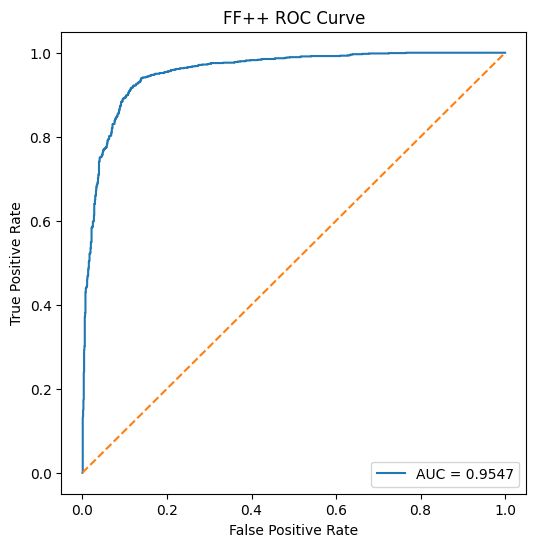

In [ ]:
fpr, tpr, _ = roc_curve(ffpp_metrics['labels'], ffpp_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {ffpp_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('FF++ ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'xception65_ffpp_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

FF++ Confusion Matrix...

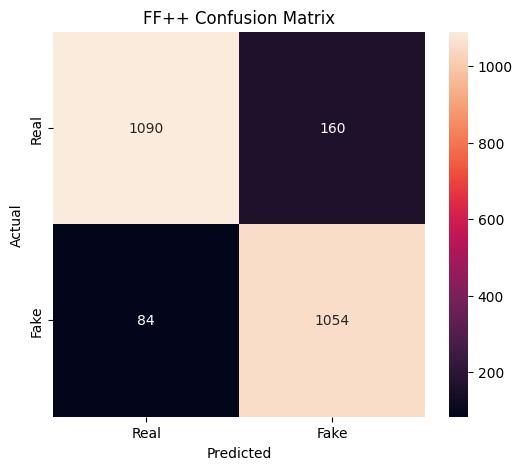

In [ ]:
import seaborn as sns

cm = confusion_matrix(ffpp_metrics['labels'], ffpp_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('FF++ Confusion Matrix')

save_path = os.path.join(output_dir, 'xception65_ffpp_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Evaluation...

In [ ]:
celeb_metrics = evaluate(model, celeb_loader, criterion)

print('\ncelebv2 evaluation results')

print(f'AUC  : {celeb_metrics['auc']:.4f}')
print(f'Accuracy  : {celeb_metrics['accuracy']:.4f}')
print(f'Precision  : {celeb_metrics['precision']:.4f}')
print(f'Recall  : {celeb_metrics['recall']:.4f}')
print(f'F1  : {celeb_metrics['f1']:.4f}')

  0%|          | 0/188 [00:00<?, ?it/s]


CelebV2 evaluation results...
AUC       : 0.7872
Accuracy  : 0.7097
Precision : 0.6738
Recall    : 0.8114
F1        : 0.7362


CelebV2 ROC Curve...

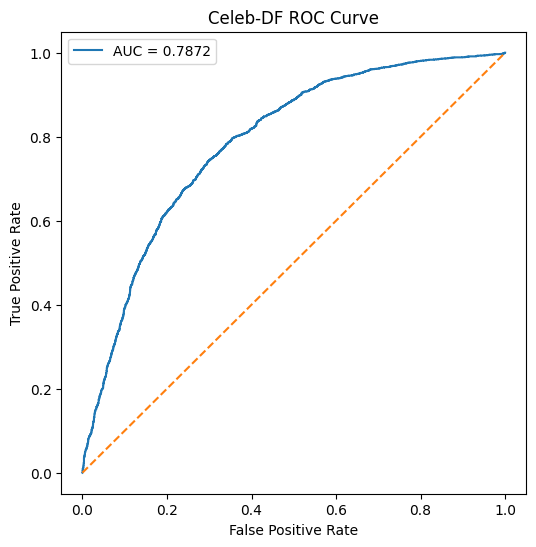

In [ ]:
fpr, tpr, _ = roc_curve(celeb_metrics['labels'], celeb_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {celeb_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Celeb-DF ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'xception65_celebv2_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Confusion Matrix...

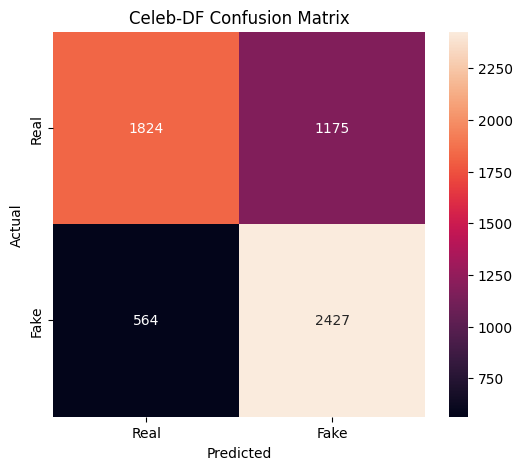

In [ ]:
cm = confusion_matrix(celeb_metrics['labels'], celeb_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Celeb-DF Confusion Matrix')

save_path = os.path.join(output_dir, 'xception65_celebv2_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

Generalization Gap...

In [ ]:
generalization_gap = (ffpp_metrics['auc'] - celeb_metrics['auc'])

print('\ngeneralization gap')

print(f'FF++ AUC  : {ffpp_metrics['auc']:.4f}')

print(f'CelebDF AUC  : {celeb_metrics['auc']:.4f}')

print(f'Gap  : {generalization_gap:.4f}')


generalization gap
FF++ AUC  : 0.9547
CelebDF AUC  : 0.7872
Gap  : 0.1674


Final Results Table...

In [ ]:
results_df = pd.DataFrame([

    {
        'Dataset':'FF++ Test',

        'AUC':ffpp_metrics['auc'],
        'Accuracy':ffpp_metrics['accuracy'],
        'Precision':ffpp_metrics['precision'],
        'Recall':ffpp_metrics['recall'],
        'F1':ffpp_metrics['f1']
    },

    {
        'Dataset':'CelebDF',

        'AUC':celeb_metrics['auc'],
        'Accuracy':celeb_metrics['accuracy'],
        'Precision':celeb_metrics['precision'],
        'Recall':celeb_metrics['recall'],
        'F1':celeb_metrics['f1']
    }
])

results_df

,Dataset,AUC,Accuracy,Precision,Recall,F1
0,FF++ Test,0.954673,0.897822,0.868204,0.926186,0.896259
1,CelebDF,0.787229,0.709683,0.673792,0.811434,0.736235


In [ ]:
results_dir = '/content/drive/MyDrive/DL_Project/results/xception_baseline/'

os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, 'xception65_results.csv'), index=False)

print('results saved.')

results saved.
